In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))
import SysSimX

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))
import fem_pendulum

---------------------

In [2]:
model = fem_pendulum.FEMPendulum(name="PendulumWithContact", group="Plant")
model._with_contact = True
model._use_gravity = True

model.init_params.angular_position_deg = 20.0
model.sim_params.tau = 0.01

model.initialize(0.0)
model.setup_simulation_diagnostics()

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [3]:
model.do_step(0, 1)

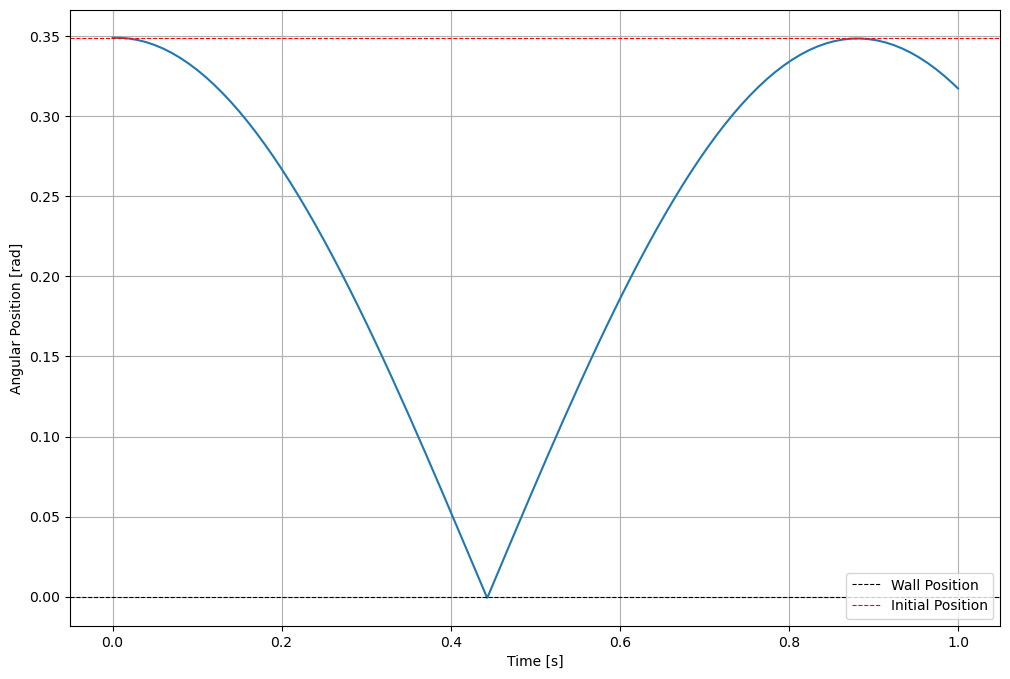

In [4]:
t_vals, q_vals = zip(*model.outputs['q'].history)

plt.figure(figsize=(12, 8))
plt.plot(t_vals, q_vals)
plt.xlabel('Time [s]')
plt.ylabel('Angular Position [rad]')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8, label="Wall Position")
plt.axhline(q_vals[0], color='r', linestyle='--', linewidth=0.8, label='Initial Position')
plt.grid()
plt.legend(loc="lower right")
plt.show()